## RECURRENCE STUDY

### Model 1: Feature Selection with Recursive Feature Elimination with Cross-Validation (RFE-CV)

In [4]:
# ----------------------------------------------------------------------------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline
import shap
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from matplotlib.lines import Line2D
# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
# Main directory where all analysis results will be stored
path = "../results/Recurrence_Model1"
input_file = "../data/Base mama FIS 2012-2014 TOR TGN Para IA.csv"

# Create the output directory
os.makedirs(path, exist_ok=True)

# Feature selection method used in this analysis
feature_selection_method = 'RECURSIVE'

# ----------------------------------------------------------------------------------------------------------------------------
# LOAD AND CLEAN DATA
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.read_csv(input_file,
    sep=";",
)

# Replace commas with dots
db = db.replace(',', '.', regex=True)

# Replace empty strings with NaN
db = db.replace(r'^\s*$', np.nan, regex=True)

# Ensure DFS120 is stored as a numerical variable
db['DFS120'] = pd.to_numeric(db['DFS120'], errors='coerce')
 
# ----------------------------------------------------------------------------------------------------------------------------
# SELECT PATIENTS WITH 120-MONTH FOLLOW-UP
# ----------------------------------------------------------------------------------------------------------------------------
# Select patients who experienced recurrence before 120 months
cas_recaiguts = db[(db['StatusDFS120'] == 'SI') & (db['DFS120'] < 120)]

# Select patients without recurrence and with complete 120-month follow-up
cas_no_recaiguts = db[(db['StatusDFS120'] == 'No') & (db['DFS120'] == 120)]

# Combine recurrence and non-recurrence groups
db = pd.concat([cas_recaiguts, cas_no_recaiguts], axis=0).reset_index(drop=True)
 
print("Dimensions després del filtratge:", db.shape)

# ----------------------------------------------------------------------------------------------------------------------------
# REMOVE UNUSED VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
db = db.drop(columns=['Cas', 'Stamenopa', 'OS120', 'DFS120', 'Tracneoad',
                      'Statuspesur', 'StatusOS120', 'Nºganglis', 'Invavasc',
                      'Luminal', 'Invaperin'], errors='ignore')

# ----------------------------------------------------------------------------------------------------------------------------
# CONVERT NUMERICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
columns_float = ['Edat', 'GangMeta', 'CD4Intra_M', 'CD4GN_M', 'CD8Intra_M', 'CD8GN_M',
                 'CD57Intra_M', 'CD57GN_M', 'FOXP3Intra_M_bis', 'FOXP3GN_M_bis',
                 'CD21Intra_M', 'CD21GN_M', 'CD68Intra_M', 'CD68GN_M', 'CD1AIntra_M',
                 'CD1AGN_M', 'CD123Intra_M', 'CD123GN_M', 'S100Intra_M', 'S100GN_M',
                 'LAMP3Intra_M', 'LAMP3GN_M', 'CD83Intra_M', 'CD83GN_M']
 
for i in columns_float:
    if i in db.columns:
        db[[i]] = db[[i]].astype(float)

# Create a copy of the dataset
db_num = db.copy()

# Remove S100Intra_M from the analysis (extensive missing data)  
db = db.drop(columns=['S100Intra_M'])
 
# ----------------------------------------------------------------------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.get_dummies(db, columns=['Grau', 'RE', 'RP', 'HER2', 'KI67', 'NodalStatus'], drop_first=True)
db = pd.get_dummies(db, columns=['StatusDFS120'])
# Remove the reference category
db = db.drop(columns=['StatusDFS120_No'])
 
# ----------------------------------------------------------------------------------------------------------------------------
# CLASS DISTRIBUTION
# ----------------------------------------------------------------------------------------------------------------------------
# Calculate the distribution of recurrence and non-recurrence cases
conteo_tipos = db['StatusDFS120_SI'].value_counts().reset_index()
conteo_tipos.columns = ['Tipus', 'Conteig']
total_elementos = db['StatusDFS120_SI'].count()
conteo_tipos['Percentatge'] = (conteo_tipos['Conteig'] / total_elementos) * 100
 
print(conteo_tipos)

# ----------------------------------------------------------------------------------------------------------------------------
# RENAME VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
variable_names = ['Age', 'Tumor Diameter', 'GangMeta', 'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-',
                  'Histological Grade II', 'Histological Grade III',
                  'RE+', 'RP+', 'HER2-', 'KI67 low', 'KI67 medium',
                  'NodalStatus_no_metastasi', 'Recurrence']
db.columns = variable_names

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE NUMERICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
variables_numericas = ['Age', 'Tumor Diameter', 'GangMeta', 'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                       'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                       'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                       'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-']
 
# ----------------------------------------------------------------------------------------------------------------------------
# TRAIN/TEST SPLIT AND CLASS BALANCING
# ----------------------------------------------------------------------------------------------------------------------------
# Define the binary recurrence outcome and predictor variables
y = db['Recurrence']
x = db.drop(columns=['Recurrence'])

# Combine predictors and target for class balancing
df_bal = pd.concat([x, y], axis=1)

# Separate recurrence and non-recurrence cases
df_pos = df_bal[df_bal['Recurrence'] == True]
df_neg = df_bal[df_bal['Recurrence'] == False]

# Randomly undersample the non-recurrence group to match the recurrence group
df_neg_sampled = df_neg.sample(n=len(df_pos), random_state=42)

# Combine both classes and shuffle the observations
df_balanced = pd.concat([df_pos, df_neg_sampled], axis=0).sample(frac=1, random_state=42)

# Define the balanced predictor matrix and target variable
x = df_balanced.drop(columns=['Recurrence'])
y = df_balanced['Recurrence']
 
# Show the new class distribution
conteo_tipos_bal = y.value_counts().reset_index()
conteo_tipos_bal.columns = ['Tipus', 'Conteig']
conteo_tipos_bal['Percentatge'] = (conteo_tipos_bal['Conteig'] / len(y)) * 100
print('\nDistribució de classes balancejada:')
print(conteo_tipos_bal)
 
# ----------------------------------------------------------------------------------------------------------------------------
# REPEATED TRAIN/TEST ANALYSIS
# ----------------------------------------------------------------------------------------------------------------------------
# The complete analysis is repeated for 100 random states.
# Each iteration uses:
#   - 80% of the data for training
#   - 20% of the data for testing
#   - stratification to preserve the target-class distribution

for i in range(0, 100):
    random_num = i
    # Create a separate directory for each random state
    os.makedirs(f'{path}/{feature_selection_method}_METHOD/{random_num}', exist_ok=True)
 
    new_file = open(f'{path}/{feature_selection_method}_METHOD/{random_num}/resultats_terminal.txt', 'w')
    new_file.write('Random State: ' + str(random_num) + '\n')
    
    #----------------------------------------------------------------------
    # TRAIN/TEST SPLIT
    #----------------------------------------------------------------------
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_num,
                                                         shuffle=True, stratify=y)
 
    #----------------------------------------------------------------------
    # CHECK CLASS DISTRIBUTION
    #----------------------------------------------------------------------
    counter = Counter(y)
    counter_test = Counter(y_test)
    new_file.write('\n' + 'y: ' + str(counter) + '\n')
    new_file.write('y test: ' + str(counter_test) + '\n')
    counter = Counter(y_train)
    new_file.write('y train: ' + str(counter) + '\n')
 
    # ----------------------------------------------------------------------
    # ITERATIVE IMPUTATION
    # ----------------------------------------------------------------------
    imputer = IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        random_state=random_num,
        sample_posterior=True
    )
 
    x_train_imp = x_train.copy()
    x_test_imp = x_test.copy()
 
    x_train_imp[variables_numericas] = imputer.fit_transform(x_train[variables_numericas])
    x_test_imp[variables_numericas] = imputer.transform(x_test[variables_numericas])
 
    # Correct negative values
    x_train_imp[variables_numericas] = x_train_imp[variables_numericas].clip(lower=0)
    x_test_imp[variables_numericas] = x_test_imp[variables_numericas].clip(lower=0)
    
    #----------------------------------------------------------------------
    # STANDARDIZATION
    #----------------------------------------------------------------------
    scaler = StandardScaler()
    scaler_fit = scaler.fit(x_train_imp[variables_numericas])
 
    x_train_scaled = x_train_imp.copy()
    x_train_scaled[variables_numericas] = scaler_fit.transform(x_train_imp[variables_numericas])
 
    x_test_scaled = x_test_imp.copy()
    x_test_scaled[variables_numericas] = scaler_fit.transform(x_test_imp[variables_numericas])
 
    # ------------------------------------------------------------
    # RANDOMIZED HYPERPARAMETER SEARCH
    # ------------------------------------------------------------
    # Three-fold stratified cross-validation is used for model selection
    cv = StratifiedKFold(3)
    
    # Hyperparameter search space for random forest
    param_dist = {
        'classifier__n_estimators': [100, 300, 500, 800],
        'classifier__max_depth': [None, 10, 20, 40],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt'],
        'classifier__bootstrap': [True, False]
    }

    # ROC AUC is used as the optimization metric
    scoring = 'roc_auc'
    new_file.write('\n' + 'Scoring: ' + str(scoring) + '\n')

    #----------------------------------------------------------------------
    # DEFINE RANDOM FOREST CLASSIFIER
    #----------------------------------------------------------------------
    rf_classifier = RandomForestClassifier(random_state=random_num)
 
    #----------------------------------------------------------------------
    # FEATURE SELECTION + RANDOMIZED SEARCH
    #----------------------------------------------------------------------  
    if x_train_scaled.shape[1] == 1:
        # Skip feature selection if only one feature
        pipeline = Pipeline([('classifier', rf_classifier)])
        random_search = RandomizedSearchCV(estimator=pipeline, scoring=scoring,
                                           param_distributions=param_dist, cv=cv, verbose=0,
                                           random_state=random_num, n_jobs=-1)
        random_search.fit(x_train_scaled, y_train)
        x_train_rfecv = x_train_scaled
        x_test_rfecv = x_test_scaled
 
    else:
        # Include Recursive Feature Elimination (RFECV) for feature selection
        pipeline = Pipeline([
            ('feature_selection', RFECV(estimator=rf_classifier, step=1, cv=cv, scoring=scoring)),
            ('classifier', rf_classifier)
        ])
        # Randomized hyperparameter search with 3-fold stratified cross-validation
        random_search = RandomizedSearchCV(estimator=pipeline, scoring=scoring,
                                           param_distributions=param_dist, cv=cv, verbose=0,
                                           random_state=random_num, n_jobs=-1)
        random_search.fit(x_train_scaled, y_train)

        # Get the selected features
        selected_features = x_train_scaled.columns[random_search.best_estimator_['feature_selection'].support_]

        # Transform the data to include only the selected features
        x_train_rfecv = pd.DataFrame(random_search.best_estimator_['feature_selection'].transform(x_train_scaled),
                                     columns=selected_features)
        x_test_rfecv = pd.DataFrame(random_search.best_estimator_['feature_selection'].transform(x_test_scaled),
                                    columns=selected_features)
 
        # ------------------------------------------------------------
        # RFECV PERFORMANCE PLOT
        # ------------------------------------------------------------
        # Retrieve the fitted RFECV object
        rfecv = random_search.best_estimator_['feature_selection']

        # Retrieve the number of features and corresponding cross-validation AUC values
        n_features = rfecv.cv_results_['n_features']
        mean_auc = rfecv.cv_results_['mean_test_score']
        std_auc = rfecv.cv_results_['std_test_score']

        # Identify the optimal number of selected features
        optimal_features = rfecv.n_features_

        # Retrieve the corresponding mean cross-validation AUC
        optimal_auc = mean_auc[n_features == optimal_features][0]

        # Plot mean cross-validation AUC across the number of selected features
        plt.figure(figsize=(7, 5))
        plt.plot(n_features, mean_auc, color='#4C72B0', lw=2)

        # Display cross-validation variability
        plt.fill_between(n_features, mean_auc - std_auc, mean_auc + std_auc, color='#4C72B0', alpha=0.25)

        # Mark the individual cross-validation values
        plt.scatter(n_features, mean_auc, color='#4C72B0', s=30)

        # Mark the optimal number of selected features
        plt.axvline(optimal_features, color='black', linestyle=':', lw=1.5)
 
        plt.xlabel('Number of selected features', fontsize=11)
        plt.ylabel('AUC', fontsize=11)
        plt.title(f'Feature selection performance (Random state {random_num})', fontsize=12, fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.4)

        # Create custom legend entries
        legend_handles = [
            Line2D([], [], color='#4C72B0', lw=2, label='Mean CV AUC'),
            Line2D([], [], color='#4C72B0', lw=8, alpha=0.25, label='Cross-validation variability'),
            Line2D([], [], color='black', lw=1.5, linestyle=':', label=f'Optimal = {optimal_features} features'),
            Line2D([], [], color='none', label=f'Optimal AUC = {optimal_auc:.3f}')
        ]
 
        plt.legend(handles=legend_handles, frameon=False, fontsize=9, loc='best')
        plt.tight_layout()
        plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/rfecv_auc_{random_num}.png',
                    dpi=300, bbox_inches='tight')
        plt.close()
 
    #----------------------------------------------------------------------
    # TRAIN FINAL RANDOM FOREST MODEL
    #----------------------------------------------------------------------
    # Retrieve the best hyperparameters identified by RandomizedSearchCV
    best_params = random_search.best_params_
    cleaned_best_params = {param.split('__')[1]: value for param, value in best_params.items()}

    # Create the final random forest model using the optimized hyperparameters
    best_rf = RandomForestClassifier(**cleaned_best_params, random_state=random_num)

    # Fit the final model using the selected training features
    best_rf.fit(x_train_rfecv, y_train)

    # Generate predictions for the independent test set
    result_rf = best_rf.predict(x_test_rfecv)
 
    #----------------------------------------------------------------------
    # CROSS-VALIDATION PERFORMANCE
    #----------------------------------------------------------------------
    # Evaluate the final model using three-fold cross-validation on the training set
    scores = cross_val_score(best_rf, x_train_rfecv, y_train, cv=cv, scoring=scoring)
    new_file.write('\n' + 'Metricas cross_validation: ' + str(scores))
    new_file.write('\n' + 'Media de cross_validation: ' + str(scores.mean()) + ' ' + str(np.std(scores)) + '\n')
 
    #----------------------------------------------------------------------
    # TEST-SET PERFORMANCE
    #----------------------------------------------------------------------
    # Generate the classification report for the independent test set
    prec_rec = classification_report(y_test, result_rf)
    new_file.write('\n' + str(prec_rec) + '\n')

    # Calculate ROC AUC on the test set
    auc = roc_auc_score(y_test, best_rf.predict_proba(x_test_rfecv)[:, 1])
    new_file.write('\n' + 'AUC: ' + str(auc) + '\n')

    # Calculate test-set accuracy
    accuracy = accuracy_score(y_test, result_rf)
    new_file.write('\n' + 'Accuracy: ' + str(accuracy) + '\n')

     # Calculate test-set recall
    recall = recall_score(y_test, result_rf)
    new_file.write('\n' + 'Recall: ' + str(recall) + '\n')
 
    # ----------------------------------------------------------------------
    # RANDOM FOREST FEATURE IMPORTANCE
    # ----------------------------------------------------------------------
    # Extract feature importance based on mean decrease in impurity
    importance = best_rf.feature_importances_

    # Retrieve the names of the selected features
    feature_names = x_test_rfecv.columns

    # Save feature importance values to the results file
    new_file.write('\n' + 'Feature importances (Gini impurity):' + '\n')
    for feature, imp in zip(feature_names, importance):
        new_file.write(f"{feature}: {imp}\n")

    # Sort features according to their importance
    sorted_idx = np.argsort(importance)
    rf_indices = np.arange(len(importance)) + 0.5
    new_file.write('\nFeatures sorted: ' + str(feature_names[sorted_idx]) + '\n')

    # Plot random forest feature importance
    plt.figure(figsize=(8, 6))
    plt.barh(rf_indices, importance[sorted_idx], height=0.7)
    plt.yticks(rf_indices, feature_names[sorted_idx])
    plt.xlabel("Feature importance (Gini impurity)")
    plt.title('Random Forest Feature Importance')
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/RF_feature_importance_{random_num}.png',
                bbox_inches='tight')
    plt.close()
 
    # ----------------------------------------------------------------------
    # SHAP ANALYSIS
    # ----------------------------------------------------------------------
    # Initialize the SHAP explainer
    try:
        explainer = shap.Explainer(best_rf.predict, x_test_rfecv)
        shap_values = explainer(x_test_rfecv)
    except:
        # Fall back to TreeExplainer if the default SHAP explainer fails
        explainer = shap.TreeExplainer(best_rf)
        shap_values = explainer(x_test_rfecv)

    # Calculate global mean absolute SHAP values
    new_file.write('\nSHAP values feature importance (global):\n')
    shap_values_per_feature = np.abs(shap_values.values[:, :, 1] if shap_values.values.ndim == 3
                                     else shap_values.values).mean(axis=0)
    for feature, val in zip(x_test_rfecv.columns, shap_values_per_feature):
        new_file.write(f"{feature}: {val}\n")
 
    # ------------------------------------------------------------------------------------------------------------------------
    # PREPARE SHAP VALUES FOR CLASS-SPECIFIC ANALYSIS
    # ------------------------------------------------------------------------------------------------------------------------
    # Extract the positive-class SHAP values when the output is three-dimensional
    shap_vals_2d = shap_values.values[:, :, 1] if shap_values.values.ndim == 3 else shap_values.values
 
    features = x_test_rfecv.columns

    # Generate predictions for the test set
    y_test_pred = best_rf.predict(x_test_rfecv)

    # Separate SHAP values according to the predicted class
    shap_class0 = shap_vals_2d[y_test_pred == 0, :]
    shap_class1 = shap_vals_2d[y_test_pred == 1, :]

    # Calculate mean absolute SHAP values for each predicted class
    shap_class0_mean = np.abs(shap_class0).mean(axis=0)
    shap_class1_mean = np.abs(shap_class1).mean(axis=0)

    # Calculate the combined feature importance across both classes
    total_importance = shap_class0_mean + shap_class1_mean

    # Sort features according to total SHAP importance
    sorted_idx = np.argsort(total_importance)
    
    # ----------------------------------------------------------------------
    # SHAP FEATURE IMPORTANCE BY CLASS
    # ----------------------------------------------------------------------
    plt.figure(figsize=(10, 8))

    # Plot the contribution of each class to the overall SHAP importance
    plt.barh(features[sorted_idx], shap_class0_mean[sorted_idx], color='blue', label='No Recurrence')
    plt.barh(features[sorted_idx], shap_class1_mean[sorted_idx],
             left=shap_class0_mean[sorted_idx], color='red', label='Recurrence')
    plt.xlabel('Mean(|SHAP value|)')
    plt.title('Feature importance por clase (SHAP)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_bar_by_class_{random_num}.png',
                bbox_inches='tight')
    plt.close()
 

    shap_values_plot = shap_values.values[:, :, 1] if shap_values.values.ndim == 3 else shap_values.values

    # Shap summary bar plot
    shap.summary_plot(shap_values_plot, x_test_rfecv, show=False, plot_type='dot')
    plt.xlabel('SHAP value (impact on model output)', fontsize=13)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_summary_point_{random_num}.png',
                bbox_inches='tight')
    plt.close()

    # Shap decision plot
    base_val = shap_values.base_values[1, 1] if shap_values.base_values.ndim == 2 else shap_values.base_values[1]
    shap.decision_plot(base_val, shap_values_plot[1, :], x_test_rfecv.columns, show=False)
    plt.savefig(f'{path}/{feature_selection_method}_METHOD/{random_num}/shap_decision_{random_num}.png',
                bbox_inches='tight')
    plt.close()
 
    new_file.close()

Dimensions després del filtratge: (121, 43)
   Tipus  Conteig  Percentatge
0  False       86     71.07438
1   True       35     28.92562

Distribució de classes balancejada:
   Tipus  Conteig  Percentatge
0   True       35         50.0
1  False       35         50.0


PermutationExplainer explainer: 15it [00:16,  1.15s/it]                                                                
C:\Users\UX534\AppData\Local\Temp\ipykernel_9000\39645490.py:344: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, x_test_rfecv, show=False, plot_type='dot')
C:\Users\UX534\AppData\Local\Temp\ipykernel_9000\39645490.py:344: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_plot, x_test_rfecv, show=False, plot_type='dot')
C:\Users\UX534\AppData\Local\Temp\ipykernel_9000\39645490.py:344: FutureWarning: The NumPy global RNG was seeded by calling `np.random.see

### Model 1 Statistics

AUC:
  Mean = 0.7621, Std = 0.1306
  Median = 0.7755, IQR = 0.1480

Accuracy:
  Mean = 0.6936, Std = 0.1113
  Median = 0.7143, IQR = 0.1429

Recall:
  Mean = 0.6914, Std = 0.1687
  Median = 0.7143, IQR = 0.2857



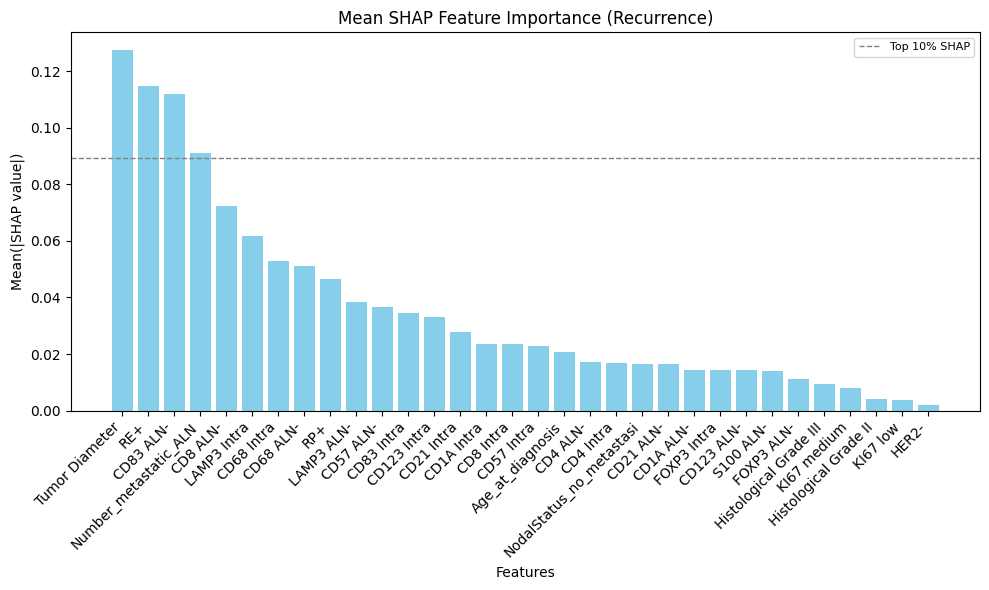

In [1]:
# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
path = "../results/Recurrence_Model1/RECURSIVE_METHOD"

# List all subfolders (each one corresponds to a random state)
files = os.listdir(path)

# Initialize lists to store model performance metrics
AUC = []
ACCURACY = []
RECALL = []

# Initialize structures to aggregate SHAP values per feature
shap_values_dict = {}

# Counter for number of model repetitions
repetitions = 0

# ----------------------------------------------------------------------------------------------------------------------------
# LOOP THROUGH ALL RESULT FILES TO EXTRACT METRICS + SHAP VALUES
# ----------------------------------------------------------------------------------------------------------------------------
for file in files:
    full_dir = os.path.join(path, file)
    file_path = os.path.join(full_dir, "resultats_terminal.txt")
    
    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} not found.")
        continue

    repetitions += 1
    with open(file_path, "r") as f:
        lines = f.readlines()

    features_sorted_reached = False

    for line in lines:
        if line.startswith('AUC'):
            AUC.append(float(line.split()[1]))  
        elif line.startswith('Accuracy'):
            ACCURACY.append(float(line.split()[1]))
        elif line.strip().startswith("Recall"):
            RECALL.append(float(line.split(":")[1].strip()))
        
        # Detect beginning of SHAP section
        if line.startswith('SHAP values '):
            features_sorted_reached = True
            continue
        
        # Parse SHAP feature importances once section starts
        if features_sorted_reached:
            line = line.strip()
            if line == "" or ":" not in line:
                continue  
            feature_name, feature_value = line.split(":")
            feature_name = feature_name.strip()
            feature_value = feature_value.strip()
            
            if feature_value == "":
                continue  
            feature_value = float(feature_value)
            
            if feature_name in shap_values_dict:
                shap_values_dict[feature_name].append(feature_value)
            else:
                shap_values_dict[feature_name] = [feature_value]

# ----------------------------------------------------------------------------------------------------------------------------
# MEAN SHAP VALUES ACROSS REPEATED RUNS
# ----------------------------------------------------------------------------------------------------------------------------
shap_values_dict_sum = {k: np.mean(v) for k, v in shap_values_dict.items()}
shap_values_dict_sum_sorted = dict(sorted(shap_values_dict_sum.items(), key=lambda item: item[1], reverse=True))

# ----------------------------------------------------------------------------------------------------------------------------
# RENAME FEATURES FOR FIGURES
# ----------------------------------------------------------------------------------------------------------------------------
rename_map = {
    'GangMeta': 'Number_metastatic_ALN',
    'Age':'Age_at_diagnosis'
}

shap_values_dict_sum_sorted = {
    rename_map.get(k, k): v for k, v in shap_values_dict_sum_sorted.items()
}

shap_values_dict_sum_sorted = {
    rename_map.get(k, k): v for k, v in shap_values_dict_sum_sorted.items()
}

# ----------------------------------------------------------------------------------------------------------------------------
# METRICS: MEAN, STD, MEDIAN, IQR
# ----------------------------------------------------------------------------------------------------------------------------
metrics = {
    'AUC': AUC,
    'Accuracy': ACCURACY,
    'Recall': RECALL
}

for metric_name, values in metrics.items():
    values_np = np.array(values)
    mean = np.mean(values_np)
    std = np.std(values_np)
    median = np.median(values_np)
    q1 = np.percentile(values_np, 25)
    q3 = np.percentile(values_np, 75)
    iqr = q3 - q1
    
    print(f"{metric_name}:")
    print(f"  Mean = {mean:.4f}, Std = {std:.4f}")
    print(f"  Median = {median:.4f}, IQR = {iqr:.4f}\n")

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(10,6))

features = list(shap_values_dict_sum_sorted.keys())

values = list(shap_values_dict_sum_sorted.values())

plt.bar(features, values, color='skyblue')

# Compute top 10% cutoff
top_10_cutoff = np.percentile(values, 90)

# Add horizontal dashed line
plt.axhline(y=top_10_cutoff, color='gray', linestyle='--', linewidth=1, label='Top 10% SHAP')

plt.title("Mean SHAP Feature Importance (Recurrence)")
plt.xlabel('Features')
plt.ylabel('Mean(|SHAP value|)')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Model 2: Incremental Feature Model Based on Importance Ranking

In [1]:
# ----------------------------------------------------------------------------------------------------------------------------
# IMPORT LIBRARIES
# ----------------------------------------------------------------------------------------------------------------------------
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from imblearn.pipeline import Pipeline
import shap
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import confusion_matrix

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
path = "../results/Recurrence_Model2"

input_file = "../data/Base mama FIS 2012-2014 TOR TGN Para IA.csv"

os.makedirs(path, exist_ok=True)

feature_selection_method = 'RECURSIVE'

# ----------------------------------------------------------------------------------------------------------------------------
# LOAD AND CLEAN DATA
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.read_csv(input_file,
    sep=";",
)

# Replace decimal commas with decimal points
db = db.replace(',', '.', regex=True)

# Replace empty or whitespace-only strings with NaN
db = db.replace(r'^\s*$', np.nan, regex=True)

# Convert DFS120 to numeric values
db['DFS120'] = pd.to_numeric(db['DFS120'], errors='coerce')

# ----------------------------------------------------------------------------------------------------------------------------
# SELECT PATIENTS WITH 120-MONTH FOLLOW-UP
# ----------------------------------------------------------------------------------------------------------------------------
# Select patients who experienced recurrence before 120 months
cas_recaiguts = db[(db['StatusDFS120'] == 'SI') & (db['DFS120'] < 120)]

# Select patients without recurrence and with complete 120-month follow-up
cas_no_recaiguts = db[(db['StatusDFS120'] == 'No') & (db['DFS120'] == 120)]

# Combine recurrence and non-recurrence groups
db = pd.concat([cas_recaiguts, cas_no_recaiguts], axis=0).reset_index(drop=True)

print("Dimensions després del filtratge:", db.shape)

# ----------------------------------------------------------------------------------------------------------------------------
# REMOVE UNUSED VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
db = db.drop(columns=['Cas', 'Stamenopa', 'OS120', 'DFS120', 'Tracneoad',
                      'Statuspesur', 'StatusOS120', 'Nºganglis', 'Invavasc',
                      'Luminal', 'Invaperin'], errors='ignore')

# ----------------------------------------------------------------------------------------------------------------------------
# CONVERT NUMERICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
columns_float = ['Edat', 'GangMeta', 'CD4Intra_M', 'CD4GN_M', 'CD8Intra_M', 'CD8GN_M',
                 'CD57Intra_M', 'CD57GN_M', 'FOXP3Intra_M_bis', 'FOXP3GN_M_bis',
                 'CD21Intra_M', 'CD21GN_M', 'CD68Intra_M', 'CD68GN_M', 'CD1AIntra_M',
                 'CD1AGN_M', 'CD123Intra_M', 'CD123GN_M', 'S100Intra_M', 'S100GN_M',
                 'LAMP3Intra_M', 'LAMP3GN_M', 'CD83Intra_M', 'CD83GN_M']

for i in columns_float:
    if i in db.columns:
        db[[i]] = db[[i]].astype(float)

# Create a copy of the dataset
db_num = db.copy()

# Remove S100Intra_M due to extensive missing data
db = db.drop(columns=['S100Intra_M'])

# ----------------------------------------------------------------------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
db = pd.get_dummies(db, columns=['Grau', 'RE', 'RP', 'HER2', 'KI67', 'NodalStatus'], drop_first=True)
db = pd.get_dummies(db, columns=['StatusDFS120'])

# Remove the reference category
db = db.drop(columns=['StatusDFS120_No'])

# ----------------------------------------------------------------------------------------------------------------------------
# CLASS DISTRIBUTION
# ----------------------------------------------------------------------------------------------------------------------------
# Calculate the distribution of recurrence and non-recurrence cases
conteo_tipos = db['StatusDFS120_SI'].value_counts().reset_index()
conteo_tipos.columns = ['Tipus', 'Conteig']
total_elementos = db['StatusDFS120_SI'].count()
conteo_tipos['Percentatge'] = (conteo_tipos['Conteig'] / total_elementos) * 100

print(conteo_tipos)

# ----------------------------------------------------------------------------------------------------------------------------
# RENAME VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
variable_names = ['Age', 'Tumor Diameter', 'GangMeta', 'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                  'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                  'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                  'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-',
                  'Histological Grade II', 'Histological Grade III',
                  'RE+', 'RP+', 'HER2-', 'KI67 low', 'KI67 medium',
                  'NodalStatus_no_metàstasi', 'Recurrence']
db.columns = variable_names

# ----------------------------------------------------------------------------------------------------------------------------
# DEFINE NUMERICAL VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
variables_numericas = ['Age', 'Tumor Diameter', 'GangMeta', 'CD4 Intra', 'CD4 ALN-', 'CD8 Intra', 'CD8 ALN-',
                       'CD57 Intra', 'CD57 ALN-', 'FOXP3 Intra', 'FOXP3 ALN-', 'CD21 Intra', 'CD21 ALN-',
                       'CD68 Intra', 'CD68 ALN-', 'CD1A Intra', 'CD1A ALN-', 'CD123 Intra', 'CD123 ALN-',
                       'S100 ALN-', 'LAMP3 Intra', 'LAMP3 ALN-', 'CD83 Intra', 'CD83 ALN-']



# ----------------------------------------------------------------------------------------------------------------------------
# TRAIN/TEST SPLIT AND MACHINE LEARNING PIPELINE WITH ITERATIVE IMPUTATION
# ----------------------------------------------------------------------------------------------------------------------------
# Define the target variable
y = db['Recurrence']

# Define the predictor variables
x = db.drop(columns=['Recurrence'])

# ----------------------------------------------------------------------------------------------------------------------------
# CLASS BALANCING
# ----------------------------------------------------------------------------------------------------------------------------
# Combine predictors and target for resampling
df_bal = pd.concat([x, y], axis=1)

# Separate recurrence and non-recurrence cases
df_pos = df_bal[df_bal['Recurrence'] == True]
df_neg = df_bal[df_bal['Recurrence'] == False]

# Count positive cases
n_pos = len(df_pos)

# Randomly undersample the negatives
df_neg_sampled = df_neg.sample(n=n_pos, random_state=42)

# Combine positive and negative cases into one balanced dataset
df_balanced = pd.concat([df_pos, df_neg_sampled], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Re-split into features (x) and target (y)
x = df_balanced.drop(columns=['Recurrence'])
y = df_balanced['Recurrence']

# Show the new class distribution
conteo_tipos_bal = y.value_counts().reset_index()
conteo_tipos_bal.columns = ['Tipus', 'Conteig']
conteo_tipos_bal['Percentatge'] = (conteo_tipos_bal['Conteig'] / len(y)) * 100
print('\nDistribució de classes balancejada:')
print(conteo_tipos_bal)

# ----------------------------------------------------------------------------------------------------------------------------
# SHAP-RANKED FEATURE LIST
# ----------------------------------------------------------------------------------------------------------------------------
# Features ranked according to their mean SHAP importance from Model 1
feature_list = ['Tumor Diameter', 'RE+','CD83 ALN-','GangMeta', 'CD8 ALN-','LAMP3 Intra','CD68 Intra','CD68 ALN-', 'RP+','LAMP3 ALN-',
                 'CD57 ALN-', 'CD83 Intra', 'CD123 Intra', 'CD21 Intra','CD1A Intra','CD8 Intra','CD57 Intra','Age','CD4 ALN-','CD4 Intra',
                'NodalStatus_no_metàstasi','CD21 ALN-','CD1A ALN-','FOXP3 Intra' ,'CD123 ALN-','S100 ALN-','FOXP3 ALN-','Histological Grade III', 
                'KI67 medium','Histological Grade II','KI67 low','HER2-']

# Initialize the list of features included in the model
feature_using = []

# Counter to keep track of how many features have been added
feature_number = 0

# ----------------------------------------------------------------------------------------------------------------------------
# SEQUENTIAL FEATURE INCLUSION
# ----------------------------------------------------------------------------------------------------------------------------
# Sequentially add SHAP-ranked features to the model
for feature1 in feature_list:
    feature_using.append(feature1)
    feature_number += 1
    print(f"Feature {feature_number}: {feature1}")

    # Repeat the train/test split and model evaluation for 100 random states
    for i in range(100):
        random_num = i
        # Create directories for the current feature set and random state
        os.makedirs(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}', exist_ok=True)
        print('Random State:', random_num)

        # Create a log file to record the results for the current iteration
        new_file = open(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/resultats_terminal.txt', 'w')
        new_file.write('Random State: ' + str(random_num) + '\n')
        
        # ----------------------------------------------------------------------
        # TRAIN/TEST SPLIT
        # ----------------------------------------------------------------------
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                             random_state=random_num, shuffle=True, stratify=y)

        # -------------------------------------------------------------
        # ITERATIVE IMPUTATION
        # -------------------------------------------------------------
        imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=random_num, sample_posterior=True)
        x_train_imp = x_train.copy()
        x_test_imp = x_test.copy()

        # Numerical columns
        x_train_imp[variables_numericas] = imputer.fit_transform(x_train[variables_numericas])
        x_test_imp[variables_numericas] = imputer.transform(x_test[variables_numericas])

        # Correct negative values
        x_train_imp[variables_numericas] = x_train_imp[variables_numericas].clip(lower=0)
        x_test_imp[variables_numericas] = x_test_imp[variables_numericas].clip(lower=0)

        # -------------------------------------------------------------
        # FEATURE SELECTION AND SCALING
        # -------------------------------------------------------------
        # Keep only the features included up to the current step and ensure all values are floating-point numbers
        x_train_scaled = x_train_imp[feature_using].astype(float)
        x_test_scaled = x_test_imp[feature_using].astype(float)

        # Scaling
        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train_scaled)
        x_test_scaled = scaler.transform(x_test_scaled)
        
        # -------------------------------------------------------------
        # RANDOM FOREST HYPERPARAMETER OPTIMIZATION
        # -------------------------------------------------------------
        # 3-fold stratified cross-validation
        cv = StratifiedKFold(3)

        # Define the hyperparameter search space
        param_dist = {
            'classifier__n_estimators': [100, 300, 500, 800],
            'classifier__max_depth': [None, 10, 20, 40],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__max_features': ['sqrt'],
            'classifier__bootstrap': [True, False]
        }

        # Use ROC AUC as the optimization metric
        scoring = 'roc_auc'
        new_file.write('\nScoring: ' + str(scoring) + '\n')

        # -------------------------------------------------------------
        # RANDOM FOREST PIPELINE
        # -------------------------------------------------------------
        pipeline = Pipeline([
            ('classifier', RandomForestClassifier(random_state=random_num))
        ])

        # Perform randomized hyperparameter search using 3-fold stratified cross-validation
        random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, cv=cv, scoring=scoring,
                                           n_jobs=-1, verbose=0, random_state=random_num, n_iter=20)
        random_search.fit(x_train_scaled, y_train)

        # ----------------------------------------------------------------------
        # TRAIN FINAL RANDOM FOREST MODE
        # ----------------------------------------------------------------------  
        # Retrieve the best hyperparameters identified during the randomized search
        best_params = {k.split('__')[1]: v for k, v in random_search.best_params_.items()}

        # Initialize the final random forest model using the optimized hyperparameters
        best_rf = RandomForestClassifier(**best_params, random_state=random_num)

        # Fit the final model on the training set
        best_rf.fit(x_train_scaled, y_train)

        # ----------------------------------------------------------------------
        # TEST SET PERFORMANCE
        # ----------------------------------------------------------------------
        y_pred = best_rf.predict(x_test_scaled)
        
        new_file.write('\nClassification report:\n' + classification_report(y_test, y_pred))
        new_file.write('\nAUC: ' + str(roc_auc_score(y_test, best_rf.predict_proba(x_test_scaled)[:, 1])))
        new_file.write('\nAccuracy: ' + str(accuracy_score(y_test, y_pred)))
        new_file.write('\nRecall: ' + str(recall_score(y_test, y_pred)))

        # ----------------------------------------------------------------------
        # CONFUSION MATRIX
        # ----------------------------------------------------------------------
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        new_file.write(f'\nTP: {tp}')
        new_file.write(f'\nTN: {tn}')
        new_file.write(f'\nFP: {fp}')
        new_file.write(f'\nFN: {fn}\n')

        # ----------------------------------------------------------------------
        # RANDOM FOREST FEATURE IMPORTANCE
        # ----------------------------------------------------------------------
        importance = best_rf.feature_importances_
        sorted_idx = np.argsort(importance)

        # Plot random forest feature importance
        plt.figure(figsize=(8, 6))
        plt.barh(range(len(importance)), importance[sorted_idx], height=0.7)
        plt.yticks(range(len(importance)), np.array(feature_using)[sorted_idx])
        plt.xlabel("Feature importance (Gini impurity)")
        plt.title('Random Forest Feature Importance')
        plt.tight_layout()
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/rf_feature_importance_{random_num}.png')
        plt.close()

        # ----------------------------------------------------------------------
        # SHAP ANALYSIS
        # ----------------------------------------------------------------------
        try:
            explainer = shap.TreeExplainer(best_rf)
            shap_values = explainer(x_test_scaled)
            if len(shap_values.shape) == 3:
                shap_values_class1 = shap_values[:, :, 1]
            else:
                shap_values_class1 = shap_values
        except Exception as e:
            print(f"TreeExplainer falló: {e}. Usando KernelExplainer como fallback.")
            explainer = shap.KernelExplainer(best_rf.predict_proba, x_train_scaled[:50])
            shap_raw = explainer.shap_values(x_test_scaled)
            shap_values_class1 = shap.Explanation(
                values=shap_raw[1],
                base_values=np.full(len(x_test_scaled), explainer.expected_value[1]),
                data=x_test_scaled
            )

        # Global feature importance
        shap_values_per_feature = np.abs(shap_values_class1.values).mean(axis=0)
        new_file.write('\nSHAP values feature importance (global):\n')
        for f, v in zip(feature_using, shap_values_per_feature):
            new_file.write(f"{f}: {v}\n")

        # Shap feature importance by predicted class
        y_test_pred = best_rf.predict(x_test_scaled)
        shap_class0_mean = np.abs(shap_values_class1.values[y_test_pred == 0, :]).mean(axis=0) if np.any(y_test_pred == 0) else np.zeros(len(feature_using))
        shap_class1_mean = np.abs(shap_values_class1.values[y_test_pred == 1, :]).mean(axis=0) if np.any(y_test_pred == 1) else np.zeros(len(feature_using))
        sorted_idx = np.argsort(shap_values_per_feature)
        sorted_features = np.array(feature_using)[sorted_idx]

        # Plot shap feature importance by class
        plt.figure(figsize=(10, 8))
        plt.barh(sorted_features, shap_class0_mean[sorted_idx], color='blue', label='No Recurrence')
        plt.barh(sorted_features, shap_class1_mean[sorted_idx], left=shap_class0_mean[sorted_idx], color='red', label='Recurrence')
        plt.xlabel('Mean(|SHAP value|)')
        plt.title('Feature importance per classe (SHAP)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_bar_by_class_{random_num}.png', bbox_inches='tight')
        plt.close()

        # Shap summary bar plot
        shap.summary_plot(shap_values_class1, x_test_scaled, show=False, plot_type='dot')
        plt.xlabel('SHAP value (impact on model output)', fontsize=13)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_summary_point_{random_num}.png', bbox_inches='tight')
        plt.close()

        # Shap decision plot
        shap.decision_plot(shap_values_class1.base_values[1], shap_values_class1.values[1, :], feature_using, show=False)
        plt.savefig(f'{path}/FEATURE_{feature_number}_{feature1}/{random_num}/shap_decision_{random_num}.png', bbox_inches='tight')
        plt.close()

        new_file.close()

Dimensions després del filtratge: (121, 43)
   Tipus  Conteig  Percentatge
0  False       86     71.07438
1   True       35     28.92562

Distribució de classes balancejada:
   Tipus  Conteig  Percentatge
0   True       35         50.0
1  False       35         50.0
Feature 1: Tumor Diameter
Random State: 0
Random State: 1
Random State: 2
Random State: 3
Random State: 4
Random State: 5
Random State: 6
Random State: 7
Random State: 8
Random State: 9


C:\Users\UX534\miniconda3\Lib\site-packages\shap\plots\_decision.py:78: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim)


Random State: 10
Random State: 11
Random State: 12
Random State: 13
Random State: 14
Random State: 15
Random State: 16
Random State: 17
Random State: 18
Random State: 19
Random State: 20
Random State: 21
Random State: 22
Random State: 23
Random State: 24
Random State: 25
Random State: 26
Random State: 27
Random State: 28
Random State: 29
Random State: 30
Random State: 31
Random State: 32
Random State: 33
Random State: 34
Random State: 35
Random State: 36
Random State: 37
Random State: 38
Random State: 39
Random State: 40
Random State: 41
Random State: 42
Random State: 43
Random State: 44
Random State: 45
Random State: 46


C:\Users\UX534\miniconda3\Lib\site-packages\shap\plots\_decision.py:78: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim)


Random State: 47
Random State: 48
Random State: 49
Random State: 50
Random State: 51
Random State: 52
Random State: 53
Random State: 54
Random State: 55
Random State: 56
Random State: 57
Random State: 58
Random State: 59
Random State: 60
Random State: 61
Random State: 62
Random State: 63
Random State: 64
Random State: 65


C:\Users\UX534\miniconda3\Lib\site-packages\shap\plots\_decision.py:78: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(xlim)


Random State: 66
Random State: 67
Random State: 68
Random State: 69
Random State: 70
Random State: 71
Random State: 72
Random State: 73
Random State: 74
Random State: 75
Random State: 76
Random State: 77
Random State: 78
Random State: 79
Random State: 80
Random State: 81
Random State: 82
Random State: 83
Random State: 84
Random State: 85
Random State: 86
Random State: 87
Random State: 88
Random State: 89
Random State: 90
Random State: 91
Random State: 92
Random State: 93
Random State: 94
Random State: 95
Random State: 96
Random State: 97
Random State: 98
Random State: 99
Feature 2: RE+
Random State: 0
Random State: 1
Random State: 2
Random State: 3
Random State: 4
Random State: 5
Random State: 6
Random State: 7
Random State: 8
Random State: 9
Random State: 10
Random State: 11
Random State: 12
Random State: 13
Random State: 14
Random State: 15
Random State: 16
Random State: 17
Random State: 18
Random State: 19
Random State: 20
Random State: 21
Random State: 22
Random State: 23
Random St

### Model 2 Statistics

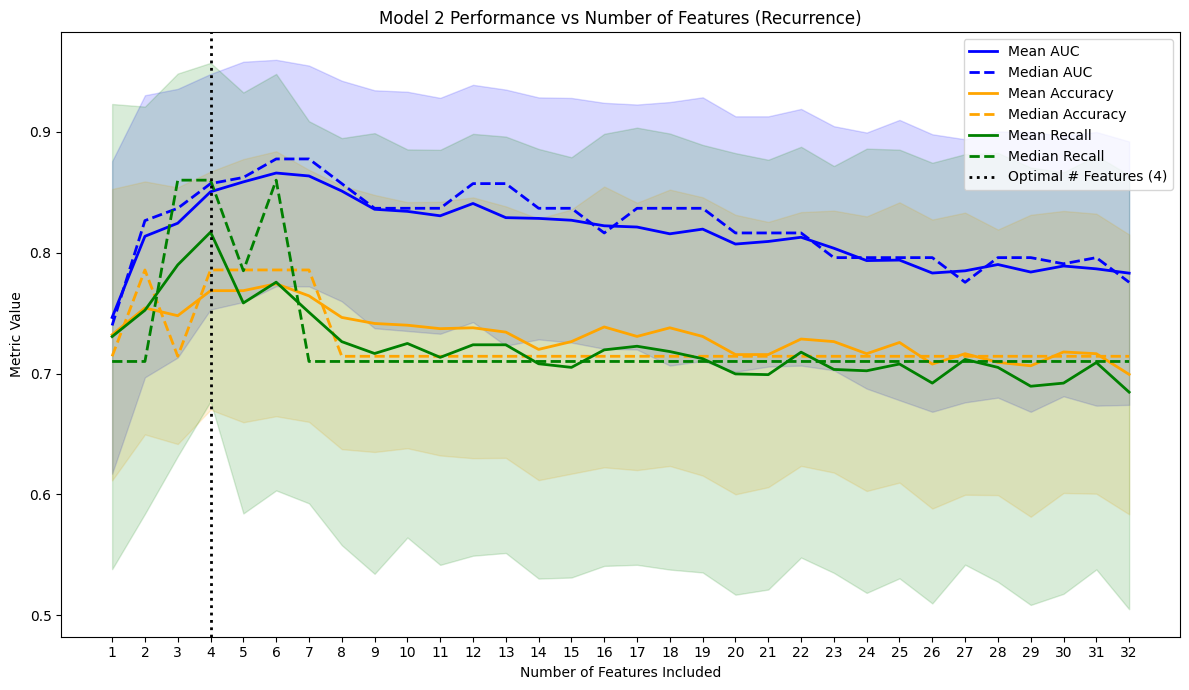


 Optimal number of features: 4

--- Final Statistics (Feature set #4) ---
AVERAGE AUC:       0.850
STD AUC:           0.097
MEDIAN AUC:        0.857
RIQ AUC:           0.122

AVERAGE ACCURACY:  0.769
STD ACCURACY:      0.099
MEDIAN ACCURACY:   0.786
RIQ ACCURACY:      0.143

AVERAGE RECALL:    0.817
STD RECALL:        0.140
MEDIAN RECALL:     0.860
RIQ RECALL:        0.150


In [2]:
# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
base_path = "../results/Recurrence_Model2"


# List all feature folders (sorted by feature number)
feature_folders = sorted(
    [f for f in os.listdir(base_path) if f.startswith("FEATURE_")],
    key=lambda x: int(x.split("_")[1])
)

# Initialize lists to store metrics for each feature count
metrics_AUC = []
metrics_Accuracy = []
metrics_Recall = []

# ----------------------------------------------------------------------------------------------------------------------------
# READ METRICS FROM ALL RESULT FILES
# ----------------------------------------------------------------------------------------------------------------------------
for folder in feature_folders:
    folder_path = os.path.join(base_path, folder)
    subfolders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]
    
    auc_list, acc_list, recall_list = [], [], []
    
    for sub in subfolders:
        result_file = os.path.join(folder_path, sub, "resultats_terminal.txt")
        if not os.path.exists(result_file):
            continue
        
        with open(result_file, "r") as f:
            lines = f.readlines()
        
        for line in lines:
            if line.startswith('AUC:'):
                auc_list.append(float(line.split(":")[1].strip()))

            elif line.startswith('Accuracy:'):
                acc_list.append(float(line.split(":")[1].strip()))

            elif line.startswith('AVERAGE RECALL:'):
                recall_list.append(float(line.split(":")[1].strip()))

            elif line.strip().startswith("True"):
                parts = line.split()
                try:
                    recall_value = float(parts[2])  
                    recall_list.append(recall_value)
                except (ValueError, IndexError):
                    pass
    
    metrics_AUC.append(auc_list)
    metrics_Accuracy.append(acc_list)
    metrics_Recall.append(recall_list)

# ----------------------------------------------------------------------------------------------------------------------------
# COMPUTE MEAN, MEDIAN AND STD FOR EACH NUMBER OF FEATURES
# ----------------------------------------------------------------------------------------------------------------------------
mean_auc = [np.mean(m) for m in metrics_AUC]
std_auc  = [np.std(m) for m in metrics_AUC]
median_auc = [np.median(m) for m in metrics_AUC]

mean_acc = [np.mean(m) for m in metrics_Accuracy]
std_acc  = [np.std(m) for m in metrics_Accuracy]
median_acc = [np.median(m) for m in metrics_Accuracy]

mean_rec = [np.mean(m) for m in metrics_Recall]
std_rec  = [np.std(m) for m in metrics_Recall]
median_rec = [np.median(m) for m in metrics_Recall]

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT PERFORMANCE EVOLUTION BY NUMBER OF FEATURES
# ----------------------------------------------------------------------------------------------------------------------------
x = np.arange(1, len(mean_auc) + 1)

plt.figure(figsize=(12,7))

# AUC
plt.plot(
    x, mean_auc,
    color='blue',
    linewidth=2,
    label='Mean AUC'
)

plt.plot(
    x, median_auc,
    color='blue',
    linestyle='--',
    linewidth=2,
    label='Median AUC'
)

plt.fill_between(
    x,
    np.array(mean_auc) - np.array(std_auc),
    np.array(mean_auc) + np.array(std_auc),
    color='blue',
    alpha=0.15
)

# Accuracy
plt.plot(
    x, mean_acc,
    color='orange',
    linewidth=2,
    label='Mean Accuracy'
)

plt.plot(
    x, median_acc,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Median Accuracy'
)

plt.fill_between(
    x,
    np.array(mean_acc) - np.array(std_acc),
    np.array(mean_acc) + np.array(std_acc),
    color='orange',
    alpha=0.15
)

# Recall
plt.plot(
    x, mean_rec,
    color='green',
    linewidth=2,
    label='Mean Recall'
)

plt.plot(
    x, median_rec,
    color='green',
    linestyle='--',
    linewidth=2,
    label='Median Recall'
)

plt.fill_between(
    x,
    np.array(mean_rec) - np.array(std_rec),
    np.array(mean_rec) + np.array(std_rec),
    color='green',
    alpha=0.15
)

# Optimal feature set
optimal_features = 4

plt.axvline(
    optimal_features,
    color='black',
    linestyle=':',
    linewidth=2,
    label=f'Optimal # Features ({optimal_features})'
)

plt.xlabel('Number of Features Included')
plt.ylabel('Metric Value')
plt.title('Model 2 Performance vs Number of Features (Recurrence)')
plt.xticks(x)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"\n Optimal number of features: {optimal_features}")

# ----------------------------------------------------------------------------------------------------------------------------
# FINAL STATISTICS (FOR THE OPTIMAL FEATURE SET)
# ----------------------------------------------------------------------------------------------------------------------------
def metric_stats(metric_list):
    metric_list = [x for x in metric_list if not np.isnan(x)]
    if len(metric_list) == 0:
        return {"mean": np.nan, "std": np.nan, "median": np.nan, "iqr": np.nan}
    return {
        "mean": np.mean(metric_list),
        "std": np.std(metric_list),
        "median": np.median(metric_list),
        "iqr": np.percentile(metric_list, 75) - np.percentile(metric_list, 25)
    }

print(f"\n--- Final Statistics (Feature set #{optimal_features}) ---")

auc_stats = metric_stats(metrics_AUC[optimal_features - 1])
acc_stats = metric_stats(metrics_Accuracy[optimal_features - 1])
rec_stats = metric_stats(metrics_Recall[optimal_features - 1])

print(f"AVERAGE AUC:       {auc_stats['mean']:.3f}")
print(f"STD AUC:           {auc_stats['std']:.3f}")
print(f"MEDIAN AUC:        {auc_stats['median']:.3f}")
print(f"RIQ AUC:           {auc_stats['iqr']:.3f}\n")

print(f"AVERAGE ACCURACY:  {acc_stats['mean']:.3f}")
print(f"STD ACCURACY:      {acc_stats['std']:.3f}")
print(f"MEDIAN ACCURACY:   {acc_stats['median']:.3f}")
print(f"RIQ ACCURACY:      {acc_stats['iqr']:.3f}\n")

print(f"AVERAGE RECALL:    {rec_stats['mean']:.3f}")
print(f"STD RECALL:        {rec_stats['std']:.3f}")
print(f"MEDIAN RECALL:     {rec_stats['median']:.3f}")
print(f"RIQ RECALL:        {rec_stats['iqr']:.3f}")


0
1
10
11
12
13
14
15
16
17
18
19
2
20
21
22
23
24
25
26
27
28
29
3
30
31
32
33
34
35
36
37
38
39
4
40
41
42
43
44
45
46
47
48
49
5
50
51
52
53
54
55
56
57
58
59
6
60
61
62
63
64
65
66
67
68
69
7
70
71
72
73
74
75
76
77
78
79
8
80
81
82
83
84
85
86
87
88
89
9
90
91
92
93
94
95
96
97
98
99


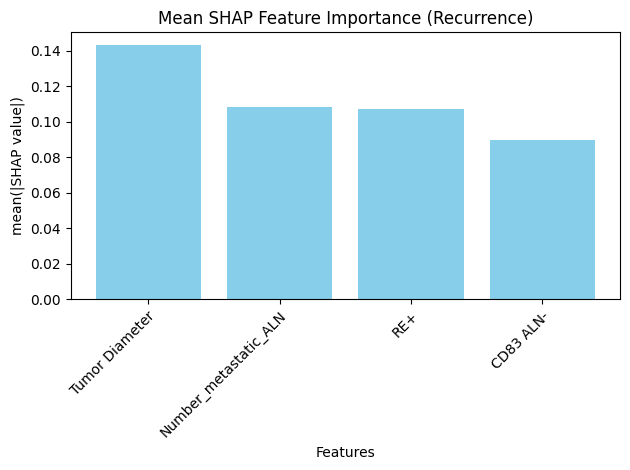

In [3]:
# ----------------------------------------------------------------------------------------------------------------------------
# INITIALIZE VARIABLES
# ----------------------------------------------------------------------------------------------------------------------------
# Define the current feature name being analyzed
feature = "FEATURE_4_GangMeta"

# ----------------------------------------------------------------------------------------------------------------------------
# PATH
# ----------------------------------------------------------------------------------------------------------------------------
path1 ="../results/Recurrence_Model2"
path = f'{path1}/{feature}'

# List all subfolders (each one corresponds to a random state)
files = os.listdir(path)

# Initialize lists to store model performance metrics and features
AUC = []
ACCURACY = []
RECALL = []
features = []

# Initialize dictionary to aggregate SHAP values per feature
shap_values_dict = {}

# Counter for number of model repetitions
repetitions =  0

# ----------------------------------------------------------------------------------------------------------------------------
# LOOP THROUGH ALL RESULT FILES TO EXTRACT METRICS + SHAP VALUES
# ----------------------------------------------------------------------------------------------------------------------------

for file in files:
    full_dir = os.path.join(path, file)
    # Skip if it's not a directory 
    if not os.path.isdir(full_dir):
        continue

    print(file)
    repetitions += 1

    file_path = os.path.join(full_dir, "resultats_terminal.txt")
    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} not found.")
        continue

    with open(file_path, "r") as f:
        lines = f.readlines()
    
    # Path to the text file containing metrics and SHAP information
    file_path = f'{path}/{file}/resultats_terminal.txt'
    lines = [line for line in open(file_path, 'r')]
    
    # Flag to identify when SHAP section starts
    features_sorted_reached = False

    for line in lines:
        if line.startswith('AUC'):
            AUC.append(float(line.split()[1]))
            
        if line.startswith('Accuracy'):
            ACCURACY.append(float(line.split()[1]))
            
        if line.strip().startswith("True"):
            parts = line.split()
            # The recall column is the 3rd numeric value (index 2)
            if len(parts) >= 3:
                RECALL.append(float(parts[2]))
            
        # Detect beginning of SHAP feature importance section   
        if line.startswith('SHAP values '):
            features_sorted_reached = True
            continue
        
        # Parse SHAP feature importances once section starts
        if features_sorted_reached:
            shap_values_lines = line.strip().split(":")
            feature_name = shap_values_lines[0].strip()
            feature_value = float(shap_values_lines[1])
            
            # Add or append SHAP values for each feature
            if feature_name in shap_values_dict:
                shap_values_dict[feature_name].append(feature_value)
            else:
                shap_values_dict[feature_name] = [feature_value]
    
# ----------------------------------------------------------------------------------------------------------------------------
# MEAN SHAP VALUES ACROSS REPEATED RUNS
# ----------------------------------------------------------------------------------------------------------------------------
shap_values_dict_sum = {}

for key, values in shap_values_dict.items():
    # Compute mean SHAP importance across all repetitions
    shap_value_sum = sum(values)
    shap_values_dict_sum[key] = shap_value_sum/repetitions
    
# Sort features by mean SHAP importance in descending order         
shap_values_dict_sum_sorted = dict(sorted(shap_values_dict_sum.items(), key=lambda item: item[1], reverse=True))

# ----------------------------------------------------------------------------------------------------------------------------
# SAVE PERFORMANCE METRICS AND CREATE TEXT FILE
# ----------------------------------------------------------------------------------------------------------------------------
# Convert metric lists to NumPy arrays and transpose for DataFrame alignment
AUC_T = np.transpose(AUC)
ACCURACY_T = np.transpose(ACCURACY)
RECALL_T = np.transpose(RECALL)

# Create a pandas DataFrame containing all performance metrics
df = pd.DataFrame([AUC, ACCURACY, RECALL]).T
df.columns = ['AUC','ACCURACY','RECALL']

# Export metrics to an Excel file
df.to_excel(f'{path}/{feature}.xlsx', index=False)

# Create or overwrite a text file for additional summary outputs
new_file = open(f'{path}/{feature}.txt', 'w')

# ----------------------------------------------------------------------------------------------------------------------------
# PLOT MEAN SHAP FEATURE IMPORTANCE
# ----------------------------------------------------------------------------------------------------------------------------
feature_names_plot = [
    name.replace("GangMeta", "Number_metastatic_ALN")
    for name in shap_values_dict_sum_sorted.keys()
]

plt.bar(
    feature_names_plot,
    shap_values_dict_sum_sorted.values(),
    color='skyblue'
)

plt.xlabel('Features')
plt.ylabel('mean(|SHAP value|)')
plt.title('Mean SHAP Feature Importance (Recurrence)')
plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.show()

### Statistical Comparison: Model 1 vs. Model 2

In [ ]:
from scipy.stats import wilcoxon

# ----------------------------------------------------------------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------------------------------------------------------------

model1_path ="../results/TumorDiameter_Model1"

model2_path ="../results/TumorDiameter_Model2"

# ----------------------------------------------------------------------------------------------------------------------------
# MODEL 1 RESULTS FOLDER
# ----------------------------------------------------------------------------------------------------------------------------

model1_folder = "RECURSIVE_METHOD"

# ----------------------------------------------------------------------------------------------------------------------------
# OPTIMAL NUMBER OF FEATURES FROM MODEL 2
# ----------------------------------------------------------------------------------------------------------------------------

optimal_features = 4


# Find the corresponding FEATURE_4 folder
model2_folder = [
    f for f in os.listdir(model2_path)
    if f.startswith(f"FEATURE_{optimal_features}_")
][0]

print(f"Model 2 optimal feature set: {model2_folder}")


# ----------------------------------------------------------------------------------------------------------------------------
# FUNCTION TO EXTRACT METRICS
# ----------------------------------------------------------------------------------------------------------------------------

def extract_metrics(result_file):

    auc = np.nan
    accuracy = np.nan
    recall = np.nan

    with open(result_file, "r", encoding="latin-1") as f:
        lines = f.readlines()

    for line in lines:

        line = line.strip()

        # AUC
        if line.startswith("AUC:"):
            auc = float(line.split(":", 1)[1].strip())

        # Accuracy
        elif line.startswith("Accuracy:"):
            accuracy = float(line.split(":", 1)[1].strip())

        # Recall - Model 1
        elif line.startswith("Recall:"):
            recall = float(line.split(":", 1)[1].strip())

        # Recall - Model 2 classification report
        elif line.startswith("True"):

            parts = line.split()

            try:
                recall_candidate = float(parts[2])

                if np.isnan(recall):
                    recall = recall_candidate

            except (ValueError, IndexError):
                pass

    return auc, accuracy, recall


# ----------------------------------------------------------------------------------------------------------------------------
# EXTRACT PAIRED RESULTS
# ----------------------------------------------------------------------------------------------------------------------------

model1_auc = []
model1_accuracy = []
model1_recall = []

model2_auc = []
model2_accuracy = []
model2_recall = []

paired_random_states = []


for random_state in range(100):

    # -----------------------------
    # Model 1
    # -----------------------------

    model1_file = os.path.join(
        model1_path,
        model1_folder,
        str(random_state),
        "resultats_terminal.txt"
    )

    # -----------------------------
    # Model 2
    # -----------------------------

    model2_file = os.path.join(
        model2_path,
        model2_folder,
        str(random_state),
        "resultats_terminal.txt"
    )

    # Only keep repetitions available in both models
    if (
        not os.path.exists(model1_file)
        or not os.path.exists(model2_file)
    ):
        continue

    auc1, acc1, rec1 = extract_metrics(model1_file)
    auc2, acc2, rec2 = extract_metrics(model2_file)

    # Keep only complete pairs
    if (
        np.isnan(auc1) or np.isnan(auc2)
        or np.isnan(acc1) or np.isnan(acc2)
        or np.isnan(rec1) or np.isnan(rec2)
    ):
        continue

    model1_auc.append(auc1)
    model2_auc.append(auc2)

    model1_accuracy.append(acc1)
    model2_accuracy.append(acc2)

    model1_recall.append(rec1)
    model2_recall.append(rec2)

    paired_random_states.append(random_state)


# ----------------------------------------------------------------------------------------------------------------------------
# NUMBER OF PAIRED REPETITIONS
# ----------------------------------------------------------------------------------------------------------------------------

print(f"Number of paired repetitions: {len(paired_random_states)}")


# ----------------------------------------------------------------------------------------------------------------------------
# WILCOXON TEST
# ----------------------------------------------------------------------------------------------------------------------------

def run_wilcoxon(model1_values, model2_values):

    statistic, p_value = wilcoxon(
        model1_values,
        model2_values,
        alternative="two-sided"
    )

    return statistic, p_value


# AUC
auc_statistic, auc_pvalue = run_wilcoxon(
    model1_auc,
    model2_auc
)

# Accuracy
accuracy_statistic, accuracy_pvalue = run_wilcoxon(
    model1_accuracy,
    model2_accuracy
)

# Recall
recall_statistic, recall_pvalue = run_wilcoxon(
    model1_recall,
    model2_recall
)


# ----------------------------------------------------------------------------------------------------------------------------
# RESULTS
# ----------------------------------------------------------------------------------------------------------------------------

print("\nWILCOXON SIGNED-RANK TEST: Model 1 vs Model 2")

print("\nAUC")
print(f"  Wilcoxon statistic: {auc_statistic:.4f}")
print(f"  p-value: {auc_pvalue:.4f}")

print("\nAccuracy")
print(f"  Wilcoxon statistic: {accuracy_statistic:.4f}")
print(f"  p-value: {accuracy_pvalue:.4f}")

print("\nRecall")
print(f"  Wilcoxon statistic: {recall_statistic:.4f}")
print(f"  p-value: {recall_pvalue:.4f}")